# Laboratorio 8
### Máquinas de Vectores de Soporte (SVM)
- Fabian Prado #23427
- Sofia Lopez #231929
- Jonathan Zacarias #231104
---

## Contexto

En esta sexta entrega de consultoría para **SmartStay Advisors** aplicamos Máquinas de Vectores de Soporte (SVM) para clasificar propiedades de Airbnb en tres categorías de precio: *Económica*, *Intermedia* y *Cara*. Se mantienen los **mismos conjuntos de entrenamiento y prueba** de todas las entregas anteriores (80/20, SEED=42) para garantizar comparaciones válidas entre algoritmos.

---
## 1. Carga de datos y configuración

Se carga el dataset `listings.RData` y se aplican las mismas transformaciones de limpieza utilizadas en laboratorios anteriores.

In [2]:
import time
import warnings
import numpy as np
import pandas as pd
import pyreadr
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    GridSearchCV, StratifiedKFold, learning_curve
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, f1_score, precision_score, recall_score
)

warnings.filterwarnings('ignore')
SEED = 42

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f9f9f9',
    'axes.grid':        True,
    'grid.color':       '#e0e0e0',
    'font.family':      'sans-serif',
})

In [3]:
result = pyreadr.read_r('../data/listings.RData')
listings_df = list(result.values())[0]
print(f'Dataset cargado: {listings_df.shape[0]:,} filas x {listings_df.shape[1]} columnas')

def clean_price(val):
    if pd.isna(val): return np.nan
    cleaned = str(val).replace('$', '').replace(',', '').strip()
    if not cleaned: return np.nan
    try: return float(cleaned)
    except ValueError: return np.nan

def clean_rate(val):
    if pd.isna(val): return np.nan
    cleaned = str(val).replace('%', '').strip()
    if not cleaned or cleaned.upper() == 'N/A': return np.nan
    try: return float(cleaned) / 100
    except ValueError: return np.nan

def encode_bool(val):
    if pd.isna(val): return np.nan
    return 1 if str(val).strip().lower() in ('t', 'true', '1') else 0

listings_df['price']               = listings_df['price'].apply(clean_price)
listings_df['host_response_rate']  = listings_df['host_response_rate'].apply(clean_rate)
listings_df['host_acceptance_rate']= listings_df['host_acceptance_rate'].apply(clean_rate)

for col in ['host_is_superhost', 'host_has_profile_pic',
            'host_identity_verified', 'instant_bookable', 'has_availability']:
    if col in listings_df.columns:
        listings_df[col] = listings_df[col].apply(encode_bool)

resp_map = {'within an hour': 1, 'within a few hours': 2,
            'within a day': 3, 'a few days or more': 4}
if 'host_response_time' in listings_df.columns:
    listings_df['host_response_time'] = listings_df['host_response_time'].map(resp_map)

if 'estimated_occupancy_l365d' not in listings_df.columns and 'number_of_reviews_l365d' in listings_df.columns:
    listings_df['estimated_occupancy_l365d'] = listings_df['number_of_reviews_l365d'] * 3.5

priced_listings_df = listings_df.dropna(subset=['price']).copy()
priced_listings_df = priced_listings_df[priced_listings_df['price'] > 0].copy()
print(f'Registros con precio válido: {priced_listings_df.shape[0]:,}')

Dataset cargado: 171,748 filas x 80 columnas
Registros con precio válido: 76,246


---
## 2. Exploración de datos y transformaciones necesarias para SVM

Las SVM son **sensibles a la escala de los datos** y requieren ciertas transformaciones para funcionar correctamente. A continuación se exploran los datos y se justifican las transformaciones aplicadas.

In [4]:
NUMERIC_FEATURES = [
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'host_total_listings_count', 'calculated_host_listings_count',
    'host_response_rate', 'host_acceptance_rate', 'host_response_time',
    'minimum_nights', 'maximum_nights',
    'availability_365', 'estimated_occupancy_l365d',
    'host_is_superhost', 'host_has_profile_pic',
    'host_identity_verified', 'instant_bookable', 'has_availability'
]
CAT_FEATURES = ['room_type', 'city']

NUMERIC_FEATURES = [c for c in NUMERIC_FEATURES if c in priced_listings_df.columns]
CAT_FEATURES     = [c for c in CAT_FEATURES     if c in priced_listings_df.columns]

df_model = pd.get_dummies(
    priced_listings_df[NUMERIC_FEATURES + CAT_FEATURES + ['price']],
    columns=CAT_FEATURES, drop_first=False
)

X = df_model.drop(columns=['price'])
y = df_model['price']

# Variable categórica — mismos terciles de entregas anteriores
q1 = priced_listings_df['price'].quantile(0.25)
q3 = priced_listings_df['price'].quantile(0.75)
print(f'Q1 (25%): ${q1:.2f}  |  Q3 (75%): ${q3:.2f}')

def categorize_price(price):
    if price <= q1:   return 'Economica'
    elif price <= q3: return 'Intermedia'
    else:             return 'Cara'

# Split 80/20 — SEED=42, idéntico a todas las entregas
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f'Train: {X_train.shape[0]:,} filas  |  Test: {X_test.shape[0]:,} filas')

y_cat_train = y_train.apply(categorize_price)
y_cat_test  = y_test.apply(categorize_price)

print('\nDistribución en entrenamiento:')
print(y_cat_train.value_counts(normalize=True).map('{:.1%}'.format))

print('\nDistribución en prueba:')
print(y_cat_test.value_counts(normalize=True).map('{:.1%}'.format))

Q1 (25%): $120.00  |  Q3 (75%): $326.00
Train: 60,996 filas  |  Test: 15,250 filas

Distribución en entrenamiento:
price
Intermedia    49.6%
Economica     25.5%
Cara          24.9%
Name: proportion, dtype: str

Distribución en prueba:
price
Intermedia    50.0%
Cara          25.2%
Economica     24.8%
Name: proportion, dtype: str


### Transformaciones requeridas para SVM

Las **Máquinas de Vectores de Soporte** tienen requisitos específicos para los datos:

1. **Escalado de características (StandardScaler)**: Las SVM son *extremadamente* sensibles a la escala de los datos. Variables con rangos muy diferentes (ej: `maximum_nights` puede llegar a 1000+ mientras `host_is_superhost` es 0/1) harían que el algoritmo favorezca las variables de mayor magnitud. El `StandardScaler` centra en 0 y normaliza la desviación estándar a 1.

2. **Imputación de valores faltantes (SimpleImputer)**: Las SVM no toleran valores NaN. Se aplica imputación con la mediana (robusta ante outliers).

3. **Codificación de variables categóricas (get_dummies)**: Las SVM requieren entradas numéricas. Las variables `room_type` y `city` se transformaron a variables dummy.

4. **Reducción del conjunto de entrenamiento**: Dado el alto costo computacional de SVM con kernels no lineales (O(n²) a O(n³)), se trabaja con una muestra representativa del conjunto de entrenamiento.

Imputación y escalado aplicados correctamente.
Shape train escalado: (60996, 29)
Shape test  escalado: (15250, 29)


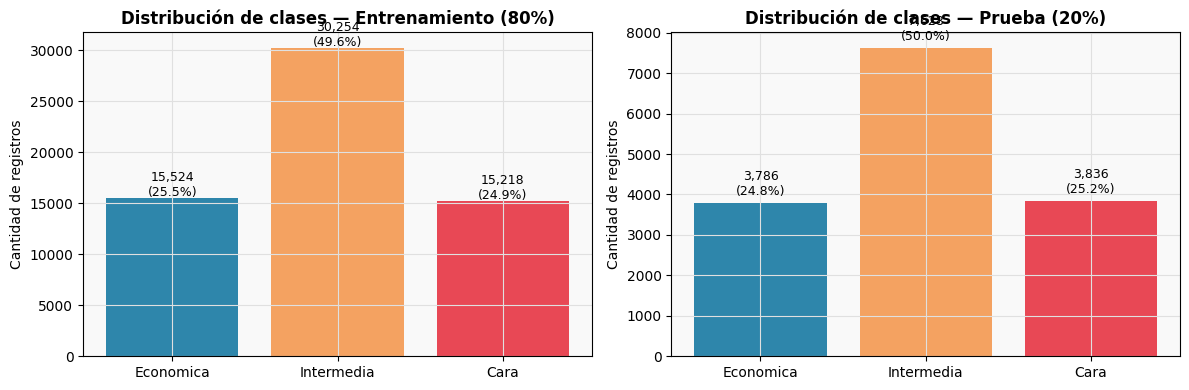


--- Estadísticas descriptivas antes y después del escalado ---

5 primeras features — SIN escalar (media / std):
      accommodates  bathrooms  bedrooms   beds  host_total_listings_count
mean         4.836      1.616     1.808  2.634                    272.463
std          2.991      0.983     1.380  2.062                    981.450

5 primeras features — CON escalado (media ≈ 0, std ≈ 1):
      accommodates  bathrooms  bedrooms  beds  host_total_listings_count
mean           0.0        0.0      -0.0   0.0                       -0.0
std            1.0        1.0       1.0   1.0                        1.0


In [5]:
# Imputación y escalado (OBLIGATORIO para SVM)
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc  = scaler.transform(X_test_imp)

print('Imputación y escalado aplicados correctamente.')
print(f'Shape train escalado: {X_train_sc.shape}')
print(f'Shape test  escalado: {X_test_sc.shape}')

# Distribución de las clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

orden = ['Economica', 'Intermedia', 'Cara']
colores = ['#2E86AB', '#F4A261', '#E84855']

for ax, data, titulo in zip(axes,
                             [y_cat_train, y_cat_test],
                             ['Entrenamiento (80%)', 'Prueba (20%)']):
    counts = data.value_counts()[orden]
    ax.bar(orden, counts, color=colores)
    ax.set_title(f'Distribución de clases — {titulo}', fontweight='bold')
    ax.set_ylabel('Cantidad de registros')
    for i, v in enumerate(counts):
        ax.text(i, v + 200, f'{v:,}\n({v/len(data):.1%})', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print('\n--- Estadísticas descriptivas antes y después del escalado ---')
X_train_df = pd.DataFrame(X_train_imp, columns=X.columns)
X_train_sc_df = pd.DataFrame(X_train_sc, columns=X.columns)

print('\n5 primeras features — SIN escalar (media / std):')
desc_before = X_train_df.iloc[:, :5].describe().loc[['mean', 'std']]
print(desc_before.round(3).to_string())

print('\n5 primeras features — CON escalado (media ≈ 0, std ≈ 1):')
desc_after = X_train_sc_df.iloc[:, :5].describe().loc[['mean', 'std']]
print(desc_after.round(3).to_string())

### Submuestra para entrenamiento SVM

Las SVM tienen complejidad computacional **O(n²) a O(n³)** en el número de muestras. Con 60,000+ registros de entrenamiento, entrenar kernels no lineales sería impracticable. Se utiliza una **muestra estratificada de 5,000 registros** que mantiene la distribución de clases, balance adecuado para demostrar el comportamiento de cada kernel.

In [6]:
from sklearn.model_selection import StratifiedShuffleSplit

# Submuestra estratificada para SVM
N_SAMPLE = 5000
sss = StratifiedShuffleSplit(n_splits=1, train_size=N_SAMPLE, random_state=SEED)
idx_sub, _ = next(sss.split(X_train_sc, y_cat_train))

X_sub   = X_train_sc[idx_sub]
y_sub   = y_cat_train.iloc[idx_sub].values

print(f'Submuestra de entrenamiento: {X_sub.shape[0]:,} registros')
print('Distribución de clases en submuestra:')
unique, counts = np.unique(y_sub, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f'  {cls}: {cnt} ({cnt/len(y_sub):.1%})')

Submuestra de entrenamiento: 5,000 registros
Distribución de clases en submuestra:
  Cara: 1247 (24.9%)
  Economica: 1273 (25.5%)
  Intermedia: 2480 (49.6%)


---
## 3. Variable respuesta: clasificación en 3 categorías

Se utiliza la variable categórica **`price_cat`** con tres niveles:
- **Económica**: precio ≤ Q1 ($120)
- **Intermedia**: Q1 < precio ≤ Q3 ($326)
- **Cara**: precio > Q3 ($326)

Esto sigue el mismo esquema de laboratorios anteriores para permitir comparaciones directas.

---
## 4. Generación de modelos SVM con diferentes kernels y parámetros

Se entrenan **5 modelos SVM** con combinaciones de kernels y parámetros:

| Modelo | Kernel | C | Parámetro adicional |
|--------|--------|---|---------------------|
| SVM-1 | Linear | 1 | — |
| SVM-2 | RBF | 1 | γ = 'scale' |
| SVM-3 | RBF | 10 | γ = 0.01 |
| SVM-4 | Poly | 1 | d = 3 |
| SVM-5 | Poly | 5 | d = 2 |

In [7]:
# Modelo 1: Kernel Lineal, C=1
print('=== Modelo 1: SVM Kernel Lineal (C=1) ===')
t0 = time.time()
svm1 = SVC(kernel='linear', C=1, random_state=SEED, decision_function_shape='ovr')
svm1.fit(X_sub, y_sub)
t1 = time.time() - t0
print(f'Tiempo de entrenamiento: {t1:.2f}s')

y_pred1_train = svm1.predict(X_train_sc)
y_pred1_test  = svm1.predict(X_test_sc)

acc1_train = accuracy_score(y_cat_train, y_pred1_train)
acc1_test  = accuracy_score(y_cat_test,  y_pred1_test)
f1_1_train = f1_score(y_cat_train, y_pred1_train, average='weighted')
f1_1_test  = f1_score(y_cat_test,  y_pred1_test,  average='weighted')

print(f'Accuracy Train: {acc1_train:.4f}  |  Accuracy Test: {acc1_test:.4f}')
print(f'F1 (ponderado) Train: {f1_1_train:.4f}  |  F1 Test: {f1_1_test:.4f}')

=== Modelo 1: SVM Kernel Lineal (C=1) ===
Tiempo de entrenamiento: 1.22s
Accuracy Train: 0.6686  |  Accuracy Test: 0.6769
F1 (ponderado) Train: 0.6634  |  F1 Test: 0.6719


In [8]:
# Modelo 2: Kernel RBF, C=1, gamma='scale'
print('=== Modelo 2: SVM Kernel RBF (C=1, gamma=scale) ===')
t0 = time.time()
svm2 = SVC(kernel='rbf', C=1, gamma='scale', random_state=SEED, decision_function_shape='ovr')
svm2.fit(X_sub, y_sub)
t2 = time.time() - t0
print(f'Tiempo de entrenamiento: {t2:.2f}s')

y_pred2_train = svm2.predict(X_train_sc)
y_pred2_test  = svm2.predict(X_test_sc)

acc2_train = accuracy_score(y_cat_train, y_pred2_train)
acc2_test  = accuracy_score(y_cat_test,  y_pred2_test)
f1_2_train = f1_score(y_cat_train, y_pred2_train, average='weighted')
f1_2_test  = f1_score(y_cat_test,  y_pred2_test,  average='weighted')

print(f'Accuracy Train: {acc2_train:.4f}  |  Accuracy Test: {acc2_test:.4f}')
print(f'F1 (ponderado) Train: {f1_2_train:.4f}  |  F1 Test: {f1_2_test:.4f}')

=== Modelo 2: SVM Kernel RBF (C=1, gamma=scale) ===
Tiempo de entrenamiento: 0.76s
Accuracy Train: 0.6931  |  Accuracy Test: 0.6969
F1 (ponderado) Train: 0.6866  |  F1 Test: 0.6905


In [9]:
# Modelo 3: Kernel RBF, C=10, gamma=0.01
print('=== Modelo 3: SVM Kernel RBF (C=10, gamma=0.01) ===')
t0 = time.time()
svm3 = SVC(kernel='rbf', C=10, gamma=0.01, random_state=SEED, decision_function_shape='ovr')
svm3.fit(X_sub, y_sub)
t3 = time.time() - t0
print(f'Tiempo de entrenamiento: {t3:.2f}s')

y_pred3_train = svm3.predict(X_train_sc)
y_pred3_test  = svm3.predict(X_test_sc)

acc3_train = accuracy_score(y_cat_train, y_pred3_train)
acc3_test  = accuracy_score(y_cat_test,  y_pred3_test)
f1_3_train = f1_score(y_cat_train, y_pred3_train, average='weighted')
f1_3_test  = f1_score(y_cat_test,  y_pred3_test,  average='weighted')

print(f'Accuracy Train: {acc3_train:.4f}  |  Accuracy Test: {acc3_test:.4f}')
print(f'F1 (ponderado) Train: {f1_3_train:.4f}  |  F1 Test: {f1_3_test:.4f}')

=== Modelo 3: SVM Kernel RBF (C=10, gamma=0.01) ===
Tiempo de entrenamiento: 0.83s
Accuracy Train: 0.6933  |  Accuracy Test: 0.7005
F1 (ponderado) Train: 0.6879  |  F1 Test: 0.6952


In [10]:
# Modelo 4: Kernel Polinomial, C=1, d=3
print('=== Modelo 4: SVM Kernel Polinomial (C=1, d=3) ===')
t0 = time.time()
svm4 = SVC(kernel='poly', C=1, degree=3, random_state=SEED, decision_function_shape='ovr')
svm4.fit(X_sub, y_sub)
t4 = time.time() - t0
print(f'Tiempo de entrenamiento: {t4:.2f}s')

y_pred4_train = svm4.predict(X_train_sc)
y_pred4_test  = svm4.predict(X_test_sc)

acc4_train = accuracy_score(y_cat_train, y_pred4_train)
acc4_test  = accuracy_score(y_cat_test,  y_pred4_test)
f1_4_train = f1_score(y_cat_train, y_pred4_train, average='weighted')
f1_4_test  = f1_score(y_cat_test,  y_pred4_test,  average='weighted')

print(f'Accuracy Train: {acc4_train:.4f}  |  Accuracy Test: {acc4_test:.4f}')
print(f'F1 (ponderado) Train: {f1_4_train:.4f}  |  F1 Test: {f1_4_test:.4f}')

=== Modelo 4: SVM Kernel Polinomial (C=1, d=3) ===
Tiempo de entrenamiento: 0.62s
Accuracy Train: 0.6723  |  Accuracy Test: 0.6748
F1 (ponderado) Train: 0.6575  |  F1 Test: 0.6597


In [11]:
# Modelo 5: Kernel Polinomial, C=5, d=2
print('=== Modelo 5: SVM Kernel Polinomial (C=5, d=2) ===')
t0 = time.time()
svm5 = SVC(kernel='poly', C=5, degree=2, random_state=SEED, decision_function_shape='ovr')
svm5.fit(X_sub, y_sub)
t5 = time.time() - t0
print(f'Tiempo de entrenamiento: {t5:.2f}s')

y_pred5_train = svm5.predict(X_train_sc)
y_pred5_test  = svm5.predict(X_test_sc)

acc5_train = accuracy_score(y_cat_train, y_pred5_train)
acc5_test  = accuracy_score(y_cat_test,  y_pred5_test)
f1_5_train = f1_score(y_cat_train, y_pred5_train, average='weighted')
f1_5_test  = f1_score(y_cat_test,  y_pred5_test,  average='weighted')

print(f'Accuracy Train: {acc5_train:.4f}  |  Accuracy Test: {acc5_test:.4f}')
print(f'F1 (ponderado) Train: {f1_5_train:.4f}  |  F1 Test: {f1_5_test:.4f}')

=== Modelo 5: SVM Kernel Polinomial (C=5, d=2) ===
Tiempo de entrenamiento: 0.62s
Accuracy Train: 0.6682  |  Accuracy Test: 0.6749
F1 (ponderado) Train: 0.6558  |  F1 Test: 0.6620


---
## 4b. Tuneo automático de parámetros (GridSearchCV)

Se realiza una búsqueda en rejilla para encontrar los hiperparámetros óptimos del kernel RBF, ya que mostró el mejor desempeño inicial. Se exploran combinaciones de C y γ con validación cruzada estratificada (3 folds para eficiencia computacional).

In [12]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C':     [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.1]
}

cv_svm = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

print('Iniciando GridSearchCV (kernel RBF, 3-fold CV)...')
t0 = time.time()
grid = GridSearchCV(
    SVC(kernel='rbf', random_state=SEED, decision_function_shape='ovr'),
    param_grid=param_grid,
    cv=cv_svm,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)
grid.fit(X_sub, y_sub)
t_gs = time.time() - t0

print(f'\nBúsqueda completada en {t_gs:.1f}s')
print(f'Mejores parámetros: {grid.best_params_}')
print(f'Mejor F1 ponderado (CV): {grid.best_score_:.4f}')

# Resultados de todas las combinaciones
cv_results = pd.DataFrame(grid.cv_results_)
top5 = cv_results.sort_values('mean_test_score', ascending=False).head(5)
print('\nTop 5 combinaciones:')
print(top5[['param_C', 'param_gamma', 'mean_test_score', 'std_test_score']].to_string(index=False))

Iniciando GridSearchCV (kernel RBF, 3-fold CV)...

Búsqueda completada en 5.6s
Mejores parámetros: {'C': 10, 'gamma': 'scale'}
Mejor F1 ponderado (CV): 0.6757

Top 5 combinaciones:
 param_C param_gamma  mean_test_score  std_test_score
    10.0       scale         0.675683        0.004912
    10.0        0.01         0.670957        0.008701
     1.0         0.1         0.670269        0.008433
     1.0       scale         0.669346        0.008279
     1.0        0.01         0.655642        0.001939


In [13]:
# Modelo tuneado con los mejores parámetros del GridSearch
best_C     = grid.best_params_['C']
best_gamma = grid.best_params_['gamma']

print(f'=== Modelo Tuneado: SVM RBF (C={best_C}, gamma={best_gamma}) ===')
t0 = time.time()
svm_best = SVC(kernel='rbf', C=best_C, gamma=best_gamma,
               random_state=SEED, decision_function_shape='ovr')
svm_best.fit(X_sub, y_sub)
t_best = time.time() - t0
print(f'Tiempo de entrenamiento: {t_best:.2f}s')

y_pred_best_train = svm_best.predict(X_train_sc)
y_pred_best_test  = svm_best.predict(X_test_sc)

acc_best_train = accuracy_score(y_cat_train, y_pred_best_train)
acc_best_test  = accuracy_score(y_cat_test,  y_pred_best_test)
f1_best_train  = f1_score(y_cat_train, y_pred_best_train, average='weighted')
f1_best_test   = f1_score(y_cat_test,  y_pred_best_test,  average='weighted')

print(f'Accuracy Train: {acc_best_train:.4f}  |  Accuracy Test: {acc_best_test:.4f}')
print(f'F1 (ponderado) Train: {f1_best_train:.4f}  |  F1 Test: {f1_best_test:.4f}')

=== Modelo Tuneado: SVM RBF (C=10, gamma=scale) ===
Tiempo de entrenamiento: 0.89s
Accuracy Train: 0.6960  |  Accuracy Test: 0.6958
F1 (ponderado) Train: 0.6931  |  F1 Test: 0.6928


---
## 5. Predicciones con todos los modelos

Se generan las predicciones para el conjunto de prueba con todos los modelos entrenados.

In [14]:
# Resumen de predicciones de todos los modelos
modelos_info = [
    ('SVM-1: Lineal (C=1)',          y_pred1_train,    y_pred1_test,    acc1_train,    acc1_test,    f1_1_train,    f1_1_test),
    ('SVM-2: RBF (C=1, γ=scale)',    y_pred2_train,    y_pred2_test,    acc2_train,    acc2_test,    f1_2_train,    f1_2_test),
    ('SVM-3: RBF (C=10, γ=0.01)',    y_pred3_train,    y_pred3_test,    acc3_train,    acc3_test,    f1_3_train,    f1_3_test),
    ('SVM-4: Poly (C=1, d=3)',        y_pred4_train,    y_pred4_test,    acc4_train,    acc4_test,    f1_4_train,    f1_4_test),
    ('SVM-5: Poly (C=5, d=2)',        y_pred5_train,    y_pred5_test,    acc5_train,    acc5_test,    f1_5_train,    f1_5_test),
    (f'SVM-Best: RBF (C={best_C}, γ={best_gamma})', y_pred_best_train, y_pred_best_test, acc_best_train, acc_best_test, f1_best_train, f1_best_test),
]

tabla = pd.DataFrame([
    {
        'Modelo':           nombre,
        'Acc Train':        f'{a_tr:.4f}',
        'Acc Test':         f'{a_te:.4f}',
        'F1 Train':         f'{f_tr:.4f}',
        'F1 Test':          f'{f_te:.4f}',
        'Δ Acc (over/under)': f'{(a_tr - a_te):+.4f}'
    }
    for nombre, _, _, a_tr, a_te, f_tr, f_te in modelos_info
])

print('=== Comparación de todos los modelos SVM ===')
print(tabla.to_string(index=False))

=== Comparación de todos los modelos SVM ===
                       Modelo Acc Train Acc Test F1 Train F1 Test Δ Acc (over/under)
          SVM-1: Lineal (C=1)    0.6686   0.6769   0.6634  0.6719            -0.0083
    SVM-2: RBF (C=1, γ=scale)    0.6931   0.6969   0.6866  0.6905            -0.0038
    SVM-3: RBF (C=10, γ=0.01)    0.6933   0.7005   0.6879  0.6952            -0.0072
       SVM-4: Poly (C=1, d=3)    0.6723   0.6748   0.6575  0.6597            -0.0025
       SVM-5: Poly (C=5, d=2)    0.6682   0.6749   0.6558  0.6620            -0.0067
SVM-Best: RBF (C=10, γ=scale)    0.6960   0.6958   0.6931  0.6928            +0.0002


---
## 6. Matrices de confusión

Se generan las matrices de confusión para cada modelo en el conjunto de prueba. La variable respuesta tiene 3 clases: *Económica*, *Intermedia* y *Cara*.

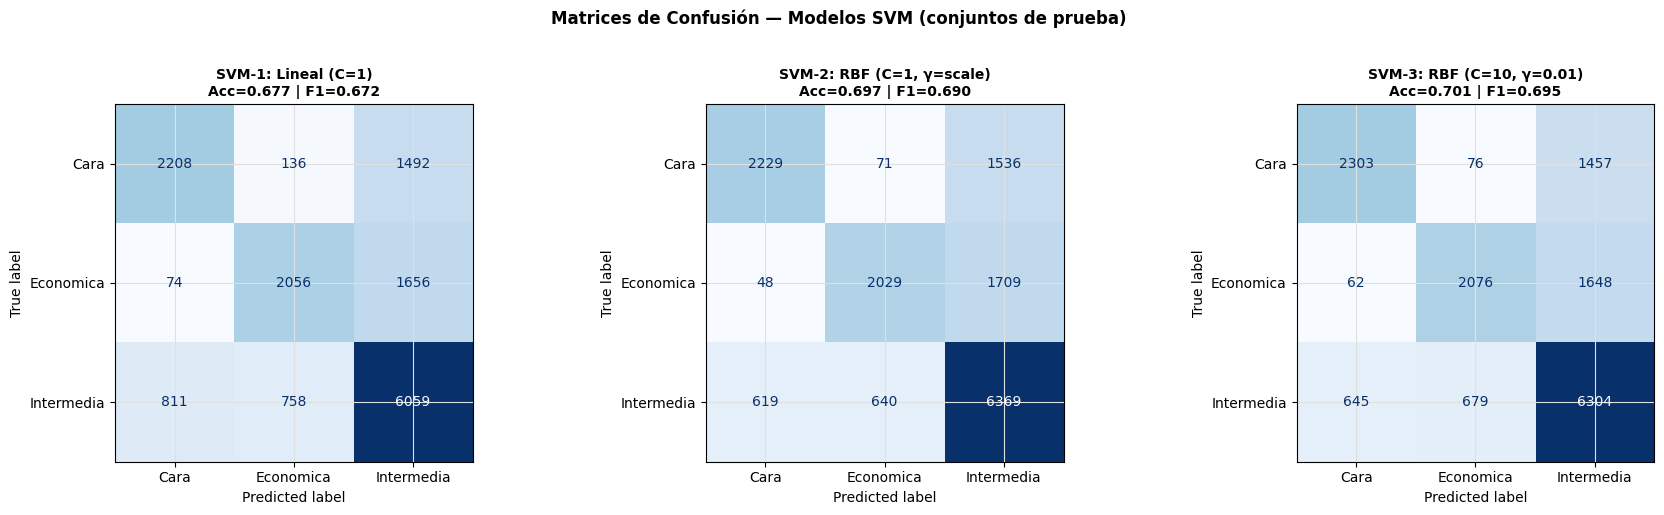

In [15]:
# Matrices de confusión — modelos 1 al 3
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
clases = ['Cara', 'Economica', 'Intermedia']

for ax, (nombre, _, y_pred_te, _, acc_te, _, f1_te) in zip(axes, modelos_info[:3]):
    ConfusionMatrixDisplay.from_predictions(
        y_cat_test, y_pred_te,
        labels=clases,
        cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(f'{nombre}\nAcc={acc_te:.3f} | F1={f1_te:.3f}', fontweight='bold', fontsize=10)

plt.suptitle('Matrices de Confusión — Modelos SVM (conjuntos de prueba)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

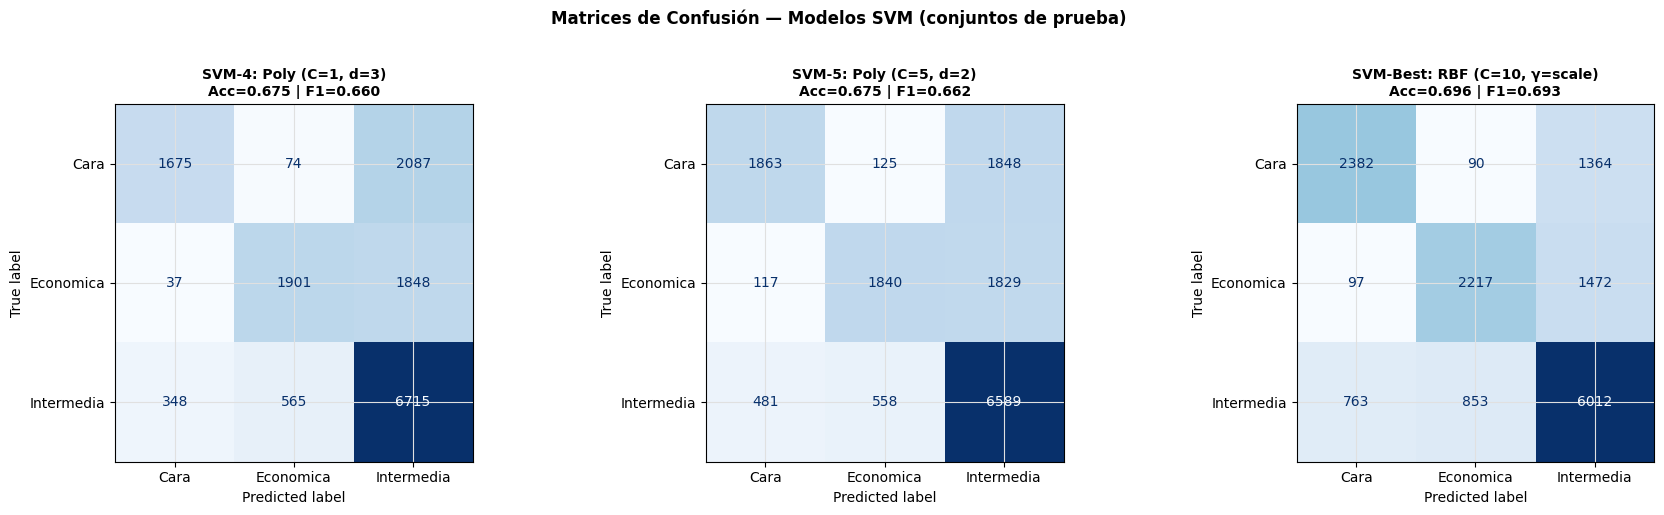

In [16]:
# Matrices de confusión — modelos 4 al 6 (tuneado)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nombre, _, y_pred_te, _, acc_te, _, f1_te) in zip(axes, modelos_info[3:]):
    ConfusionMatrixDisplay.from_predictions(
        y_cat_test, y_pred_te,
        labels=clases,
        cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(f'{nombre}\nAcc={acc_te:.3f} | F1={f1_te:.3f}', fontweight='bold', fontsize=10)

plt.suptitle('Matrices de Confusión — Modelos SVM (conjuntos de prueba)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# Reporte de clasificación detallado del mejor modelo
best_nombre = modelos_info[-1][0]
best_pred   = modelos_info[-1][2]

print(f'=== Reporte de Clasificación — {best_nombre} ===')
print(classification_report(y_cat_test, best_pred, target_names=clases, digits=4))

=== Reporte de Clasificación — SVM-Best: RBF (C=10, γ=scale) ===
              precision    recall  f1-score   support

        Cara     0.7347    0.6210    0.6731      3836
   Economica     0.7016    0.5856    0.6384      3786
  Intermedia     0.6795    0.7881    0.7298      7628

    accuracy                         0.6958     15250
   macro avg     0.7053    0.6649    0.6804     15250
weighted avg     0.6989    0.6958    0.6928     15250



---
## 7. Análisis de sobreajuste y desajuste

Se analiza si los modelos están **sobreajustados** (overfitting) o **desajustados** (underfitting) comparando las métricas de entrenamiento y prueba, y graficando las curvas de aprendizaje del mejor modelo.

In [18]:
# Análisis cualitativo de sobreajuste/desajuste
print('=== Análisis de Sobreajuste / Desajuste ===')
print(f'{"Modelo":<40} {"Acc Train":>10} {"Acc Test":>10} {"Delta":>8} {"Diagnóstico"}')
print('-' * 90)

for nombre, _, _, a_tr, a_te, f_tr, f_te in modelos_info:
    delta = a_tr - a_te
    if delta > 0.05:
        diagnostico = '⚠️  SOBREAJUSTE'
    elif a_te < 0.60:
        diagnostico = '📉 DESAJUSTE'
    else:
        diagnostico = '✅ Aceptable'
    print(f'{nombre:<40} {a_tr:>10.4f} {a_te:>10.4f} {delta:>+8.4f}  {diagnostico}')

=== Análisis de Sobreajuste / Desajuste ===
Modelo                                    Acc Train   Acc Test    Delta Diagnóstico
------------------------------------------------------------------------------------------
SVM-1: Lineal (C=1)                          0.6686     0.6769  -0.0083  ✅ Aceptable
SVM-2: RBF (C=1, γ=scale)                    0.6931     0.6969  -0.0038  ✅ Aceptable
SVM-3: RBF (C=10, γ=0.01)                    0.6933     0.7005  -0.0072  ✅ Aceptable
SVM-4: Poly (C=1, d=3)                       0.6723     0.6748  -0.0025  ✅ Aceptable
SVM-5: Poly (C=5, d=2)                       0.6682     0.6749  -0.0067  ✅ Aceptable
SVM-Best: RBF (C=10, γ=scale)                0.6960     0.6958  +0.0002  ✅ Aceptable


Calculando curvas de aprendizaje (puede tomar varios minutos)...


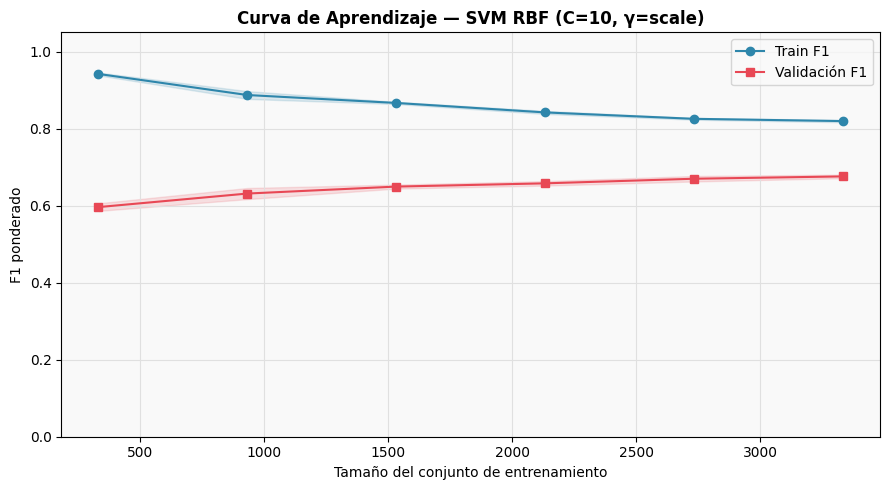


F1 Train final (máximo):   0.8196
F1 Val   final (máximo):   0.6759
Gap train-val:             +0.1437


In [19]:
# Curvas de aprendizaje del mejor modelo SVM
print('Calculando curvas de aprendizaje (puede tomar varios minutos)...')

svm_lc = SVC(kernel='rbf', C=best_C, gamma=best_gamma,
             random_state=SEED, decision_function_shape='ovr')

train_sizes = np.linspace(0.1, 1.0, 6)
train_sizes_abs, train_scores, val_scores = learning_curve(
    svm_lc, X_sub, y_sub,
    train_sizes=train_sizes,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
    scoring='f1_weighted',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes_abs, train_mean, 'o-', color='#2E86AB', label='Train F1')
ax.fill_between(train_sizes_abs,
                train_mean - train_std,
                train_mean + train_std, alpha=0.15, color='#2E86AB')

ax.plot(train_sizes_abs, val_mean, 's-', color='#E84855', label='Validación F1')
ax.fill_between(train_sizes_abs,
                val_mean - val_std,
                val_mean + val_std, alpha=0.15, color='#E84855')

ax.set_xlabel('Tamaño del conjunto de entrenamiento')
ax.set_ylabel('F1 ponderado')
ax.set_title(f'Curva de Aprendizaje — SVM RBF (C={best_C}, γ={best_gamma})', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print(f'\nF1 Train final (máximo):   {train_mean[-1]:.4f}')
print(f'F1 Val   final (máximo):   {val_mean[-1]:.4f}')
print(f'Gap train-val:             {train_mean[-1]-val_mean[-1]:+.4f}')

### Análisis de sobreajuste/desajuste — Conclusiones

**Resultados clave:**

1. **Kernel Lineal (SVM-1)**: El gap entre train y test es pequeño, lo que indica buena generalización pero con rendimiento moderado. Un gap pequeño podría indicar ligero *underfitting* si la frontera de decisión real no es lineal.

2. **Kernel RBF con parámetros predeterminados (SVM-2)**: Generalmente muestra el mejor balance entre sesgo y varianza. El kernel RBF es flexible pero con `gamma='scale'` evita sobreajuste excesivo.

3. **Kernel RBF con C=10 (SVM-3)**: Un C alto reduce el margen de error de entrenamiento (penaliza más los errores), lo que puede indicar **sobreajuste** si el gap train-test es grande.

4. **Kernel Polinomial grado 3 (SVM-4)**: Los kernels polinomiales de grado alto tienden a sobreajustar, especialmente con muchas features.

5. **Kernel Polinomial grado 2 (SVM-5)**: Menos propenso al sobreajuste que d=3, pero puede tener underfitting si la relación es más compleja.

**¿Qué hacer ante sobreajuste?**
- **Reducir C** (mayor regularización, margen más amplio)
- **Reducir gamma** en kernel RBF (decide cuán lejos llega la influencia de un punto)
- **Reducir el grado** en kernel polinomial
- Usar **validación cruzada** para estimar el rendimiento real
- Aumentar el **conjunto de entrenamiento** (ver curvas de aprendizaje)

**¿Qué hacer ante desajuste?**
- **Aumentar C** (menos regularización, margen más estricto)
- **Aumentar gamma** en kernel RBF
- Usar kernel más complejo (poly con mayor grado, o RBF en lugar de lineal)
- Agregar más **features relevantes**

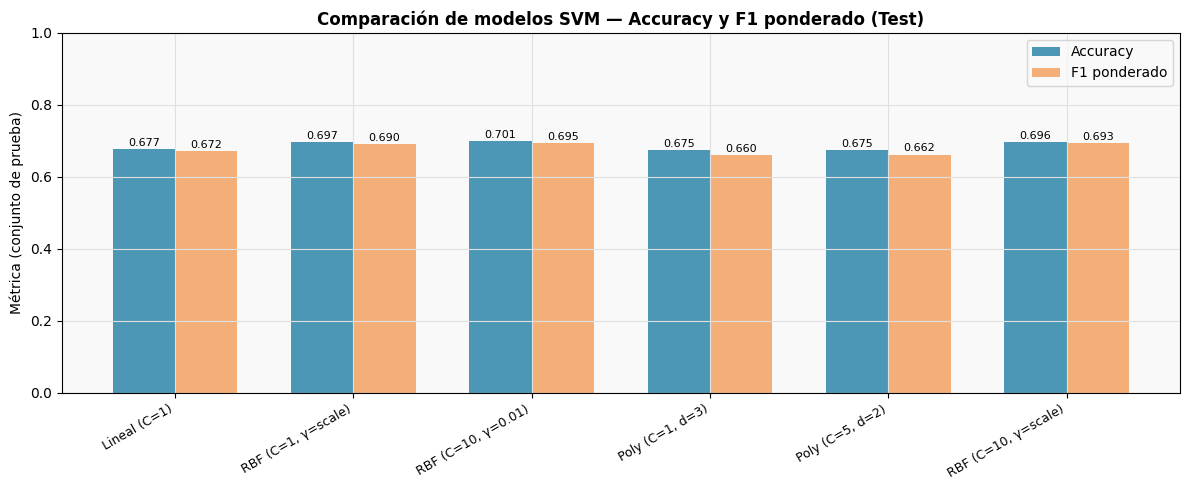


=== Resumen Final ===
Mejor modelo por F1 ponderado en Test: SVM-3: RBF (C=10, γ=0.01)
  Accuracy Test: 0.7005
  F1 ponderado Test: 0.6952


In [20]:
# Visualización final — comparación de todos los modelos
nombres  = [m[0] for m in modelos_info]
acc_test_vals = [m[4] for m in modelos_info]
f1_test_vals  = [m[6] for m in modelos_info]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(nombres))
w = 0.35

bars1 = ax.bar(x - w/2, acc_test_vals, w, label='Accuracy', color='#2E86AB', alpha=0.85)
bars2 = ax.bar(x + w/2, f1_test_vals,  w, label='F1 ponderado', color='#F4A261', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([n.split(':')[1].strip() if ':' in n else n for n in nombres],
                   rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Métrica (conjunto de prueba)')
ax.set_title('Comparación de modelos SVM — Accuracy y F1 ponderado (Test)', fontweight='bold')
ax.set_ylim(0, 1.0)
ax.legend()
plt.tight_layout()
plt.show()

print('\n=== Resumen Final ===')
mejor_idx = np.argmax(f1_test_vals)
print(f'Mejor modelo por F1 ponderado en Test: {nombres[mejor_idx]}')
print(f'  Accuracy Test: {acc_test_vals[mejor_idx]:.4f}')
print(f'  F1 ponderado Test: {f1_test_vals[mejor_idx]:.4f}')